### loading data

In [ ]:
import pandas as pd

# reading files
users_base = pd.read_csv('users_base.csv')
payments = pd.read_csv('payments.csv')
peak_time = pd.read_csv('peak_time.csv')
vouchers = pd.read_csv('vouchers.csv')
categories = pd.read_csv('categories.csv')

# merging
print("مرحله 1: ادغام users_base و payments...")
users = users_base.merge(payments, on='user_id', how='left')
print(f"  {users.shape}")

print("مرحله 2: ادغام با peak_time...")
users = users.merge(peak_time, on='user_id', how='left')
print(f"  {users.shape}")

print("مرحله 3: ادغام با vouchers...")
users = users.merge(vouchers, on='user_id', how='left')
print(f"  {users.shape}")

print("مرحله 4: ادغام با categories...")
users = users.merge(categories, on='user_id', how='left')
print(f"  {users.shape}")

print(f"\n✅ جدول نهایی: {users.shape}")
print(f"ستون‌ها: {list(users.columns)}")

users.to_csv('users_final.csv', index=False)
print("✅ فایل users_final.csv ذخیره شد")

users.head()


مرحله 1: ادغام users_base و payments...
  (936056, 8)
مرحله 2: ادغام با peak_time...
  (936056, 9)
مرحله 3: ادغام با vouchers...
  (936056, 12)
مرحله 4: ادغام با categories...
  (936056, 13)

✅ جدول نهایی: (936056, 13)
ستون‌ها: ['user_id', 'create_date', 'total_purchases', 'active_purchase_dates', 'unique_movies_purchased', 'discounted_purchases', 'discount_percentage', 'total_purchase_value', 'peak_activity_time', 'total_vouchers', 'total_voucher_value', 'total_voucher_days', 'fav_category']
✅ فایل users_final.csv ذخیره شد


,user_id,create_date,total_purchases,active_purchase_dates,unique_movies_purchased,discounted_purchases,discount_percentage,total_purchase_value,peak_activity_time,total_vouchers,total_voucher_value,total_voucher_days,fav_category
0,28b3d238-79de-4ac9-806b-33afedd12f81,2026-01-01,2.0,2.0,2.0,0.0,0.00,90.00,morning,NaN,NaN,NaN,Horror
1,0f41fd48-2ecf-4c19-ad0b-22fb8edadbd0,2026-01-01,3.0,3.0,3.0,1.0,33.33,128.25,morning,NaN,NaN,NaN,Action
2,931396ec-bdd4-4112-a9a2-a0541db5e72a,2026-01-01,8.0,8.0,8.0,1.0,12.50,353.25,evening,NaN,NaN,NaN,Music
3,7f2d9800-0fb1-4fb5-ab4a-cc42a7fa3998,2026-01-01,4.0,4.0,4.0,0.0,0.00,180.00,night,3.0,35.0,27.0,Classics
4,5e910d78-3b8f-4ceb-97d6-684c86a5b72f,2026-01-01,3.0,3.0,3.0,1.0,33.33,125.00,evening,2.0,25.0,20.0,Comedy


In [3]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 936056 entries, 0 to 936055
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   user_id                  936056 non-null  object 
 1   create_date              936056 non-null  object 
 2   total_purchases          699250 non-null  float64
 3   active_purchase_dates    699250 non-null  float64
 4   unique_movies_purchased  699250 non-null  float64
 5   discounted_purchases     699250 non-null  float64
 6   discount_percentage      699250 non-null  float64
 7   total_purchase_value     699250 non-null  float64
 8   peak_activity_time       894787 non-null  object 
 9   total_vouchers           115579 non-null  float64
 10  total_voucher_value      115579 non-null  float64
 11  total_voucher_days       115579 non-null  float64
 12  fav_category             731153 non-null  object 
dtypes: float64(9), object(4)
memory usage: 92.8+ MB


### Cleaning data

In [ ]:
import pandas as pd
import numpy as np


financial_cols = ['total_purchases', 'active_purchase_dates', 'unique_movies_purchased',
                  'discounted_purchases', 'discount_percentage', 'total_purchase_value']
users[financial_cols] = users[financial_cols].fillna(0)

voucher_cols = ['total_vouchers', 'total_voucher_value', 'total_voucher_days']
users[voucher_cols] = users[voucher_cols].fillna(0)

# peak_activity_time: پر کردن با 'Unknown'
users['peak_activity_time'] = users['peak_activity_time'].fillna('Unknown')

# fav_category: پر کردن با 'Unknown'
users['fav_category'] = users['fav_category'].fillna('Unknown')


In [5]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = ['total_purchases', 'active_purchase_dates', 'unique_movies_purchased',
                    'discounted_purchases', 'discount_percentage', 'total_purchase_value',
                    'total_vouchers', 'total_voucher_value', 'total_voucher_days']

categorical_features = ['peak_activity_time', 'fav_category']

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])


### Elbow Methode

در حال محاسبه Inertia برای تعداد مختلف خوشه‌ها...


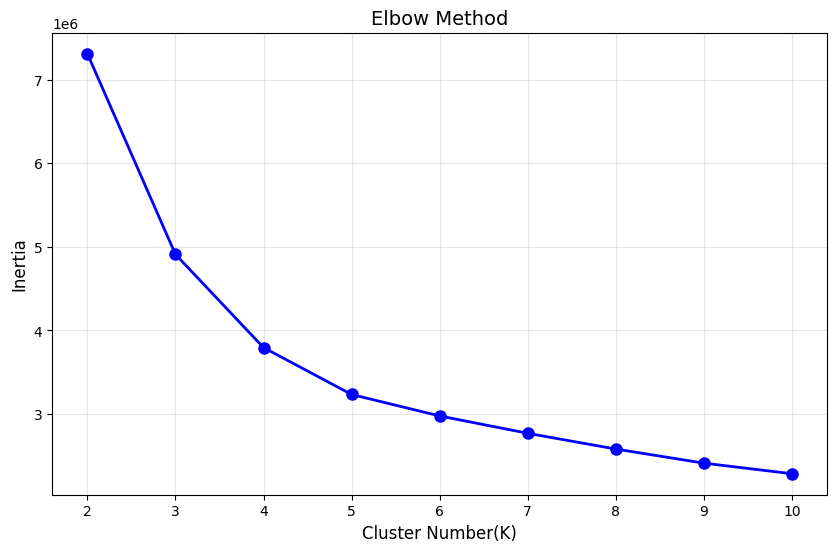

In [ ]:
import matplotlib.pyplot as plt

# Elbow Method
inertias = []
K_range = range(2, 11)  # تست از ۲ تا ۱۰ خوشه

print("در حال محاسبه Inertia برای تعداد مختلف خوشه‌ها...")

for k in K_range:
    # ساخت Pipeline موقت فقط برای محاسبه Inertia
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    pipeline_temp = Pipeline([
        ('preprocessor', preprocessor),
        ('kmeans', kmeans_temp)
    ])
    
    # محاسبه Inertia
    pipeline_temp.fit(users)
    inertias.append(pipeline_temp.named_steps['kmeans'].inertia_)

# ۳. رسم نمودار آرنج
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Cluster Number(K)", fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title("Elbow Method", fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()


### Clustering

In [ ]:
optimal_k = 4

print(f"تعداد خوشه‌های انتخابی: {optimal_k}")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
pipeline_final = Pipeline([
    ('preprocessor', preprocessor),
    ('kmeans', kmeans_final)
])

users['cluster'] = pipeline_final.fit_predict(users)

تعداد خوشه‌های انتخابی: 4


In [8]:
users


,user_id,create_date,total_purchases,active_purchase_dates,unique_movies_purchased,discounted_purchases,discount_percentage,total_purchase_value,peak_activity_time,total_vouchers,total_voucher_value,total_voucher_days,fav_category,cluster
0,28b3d238-79de-4ac9-806b-33afedd12f81,2026-01-01,2.0,2.0,2.0,0.0,0.00,90.00,morning,0.0,0.0,0.0,Horror,0
1,0f41fd48-2ecf-4c19-ad0b-22fb8edadbd0,2026-01-01,3.0,3.0,3.0,1.0,33.33,128.25,morning,0.0,0.0,0.0,Action,1
2,931396ec-bdd4-4112-a9a2-a0541db5e72a,2026-01-01,8.0,8.0,8.0,1.0,12.50,353.25,evening,0.0,0.0,0.0,Music,2
3,7f2d9800-0fb1-4fb5-ab4a-cc42a7fa3998,2026-01-01,4.0,4.0,4.0,0.0,0.00,180.00,night,3.0,35.0,27.0,Classics,3
4,5e910d78-3b8f-4ceb-97d6-684c86a5b72f,2026-01-01,3.0,3.0,3.0,1.0,33.33,125.00,evening,2.0,25.0,20.0,Comedy,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
936051,675e0e58-a31b-4d1d-b991-6b7d1779c61b,2026-06-12,0.0,0.0,0.0,0.0,0.00,0.00,Unknown,0.0,0.0,0.0,Unknown,0
936052,e79d557d-efbf-4764-a102-2af56809a13c,2026-06-12,0.0,0.0,0.0,0.0,0.00,0.00,Unknown,0.0,0.0,0.0,Unknown,0
936053,10ef8b0e-204c-41d9-9a05-e9c20c566b14,2026-06-12,0.0,0.0,0.0,0.0,0.00,0.00,Unknown,0.0,0.0,0.0,Unknown,0
936054,6bde2521-6dbf-4e89-b2b9-39f36db2a50d,2026-06-12,0.0,0.0,0.0,0.0,0.00,0.00,Unknown,0.0,0.0,0.0,Unknown,0


### Analyzing Clusters

In [ ]:
print("Cluster Profile:\n")
cluster_profile = users.groupby('cluster')[numeric_features].mean().round(2)
print(cluster_profile)

print("Fav Category in Each Cluster:\n")
for cluster in range(optimal_k):
    top_cats = users[users['cluster'] == cluster]['fav_category'].value_counts().head(3)
    print(f"\nخوشه {cluster}:")
    for cat, count in top_cats.items():
        print(f"  {cat}: {count}")

print("Users Count in Each Cluster:\n")
print(users['cluster'].value_counts().sort_index())


Cluster Profile:

         total_purchases  active_purchase_dates  unique_movies_purchased  \
cluster                                                                    
0                   1.15                   1.13                     1.15   
1                   2.94                   2.83                     2.93   
2                   8.11                   7.70                     8.09   
3                   2.48                   2.42                     2.48   

         discounted_purchases  discount_percentage  total_purchase_value  \
cluster                                                                    
0                        0.00                 0.00                 51.81   
1                        1.25                53.26                122.43   
2                        0.56                 6.40                360.67   
3                        0.34                11.72                106.71   

         total_vouchers  total_voucher_value  total_voucher_days  
c

Dormant
(1.2, 52)
Deal Hunter
(2.9, 122)
VIP
(8.1, 361)
Coupon Hoarder
(2.5, 107)


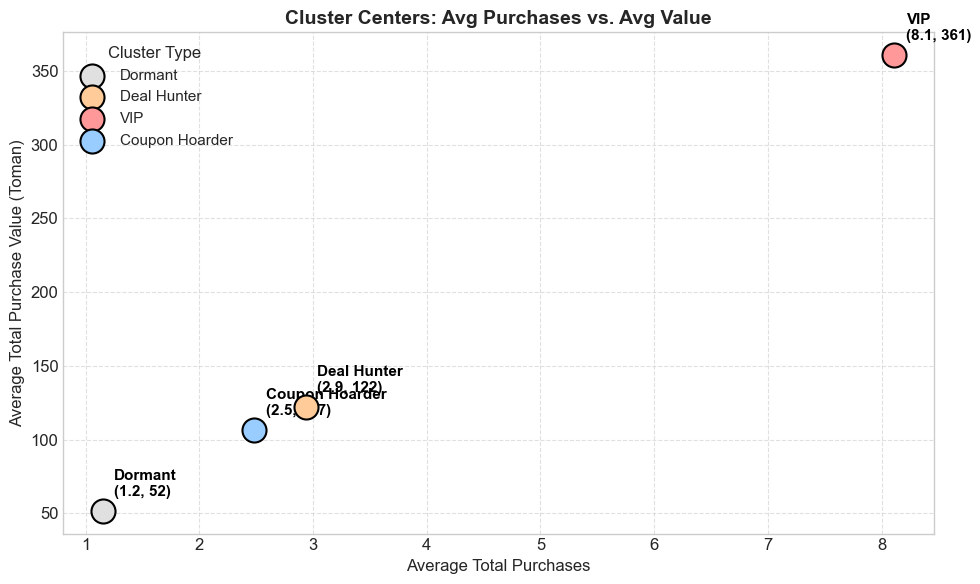

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# محاسبه میانگین برای هر خوشه
cluster_stats = users.groupby('cluster')[['total_purchases', 'total_purchase_value']].mean().reset_index()

# تعریف رنگ‌ها و لیبل‌ها
palette = {
    0: '#e0e0e0',  # Dormant
    1: '#ffcc99',  # Deal Hunter
    2: '#ff9999',  # VIP
    3: '#99ccff'   # Coupon Hoarder
}

cluster_labels = {
    0: 'Dormant',
    1: 'Deal Hunter',
    2: 'VIP',
    3: 'Coupon Hoarder'
}

plt.figure(figsize=(10, 6))

# رسم نمودار خطی/نقطه‌ای برای میانگین‌ها
for cluster in cluster_stats['cluster']:
    row = cluster_stats[cluster_stats['cluster'] == cluster].iloc[0]
    x = row['total_purchases']
    y = row['total_purchase_value']
    label = cluster_labels[cluster]
    color = palette[cluster]
    
    print( f'{label}\n({x:.1f}, {y:.0f})')


    # رسم نقطه بزرگ
    plt.scatter(x, y, s=300, c=color, label=label, edgecolors='black', linewidth=1.5, zorder=10)
    
    # اضافه کردن متن کنار نقطه
    plt.text(x + 0.1, y + 10, f'{label}\n({x:.1f}, {y:.0f})', fontsize=11, fontweight='bold', color='black')

plt.title('Cluster Centers: Avg Purchases vs. Avg Value', fontsize=14, fontweight='bold')
plt.xlabel('Average Total Purchases', fontsize=12)
plt.ylabel('Average Total Purchase Value (Toman)', fontsize=12)
plt.legend(title='Cluster Type', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


Dormant
Comedy/Music
0% Discount 1.15 51.81
Deal Hunter
Action/Sci-Fi
53% Discount 2.94 122.43
VIP
Horror/Comedy
6% Discount 8.11 360.67
Coupon Hoarder
Comedy/Classics
12% Discount 2.48 106.71


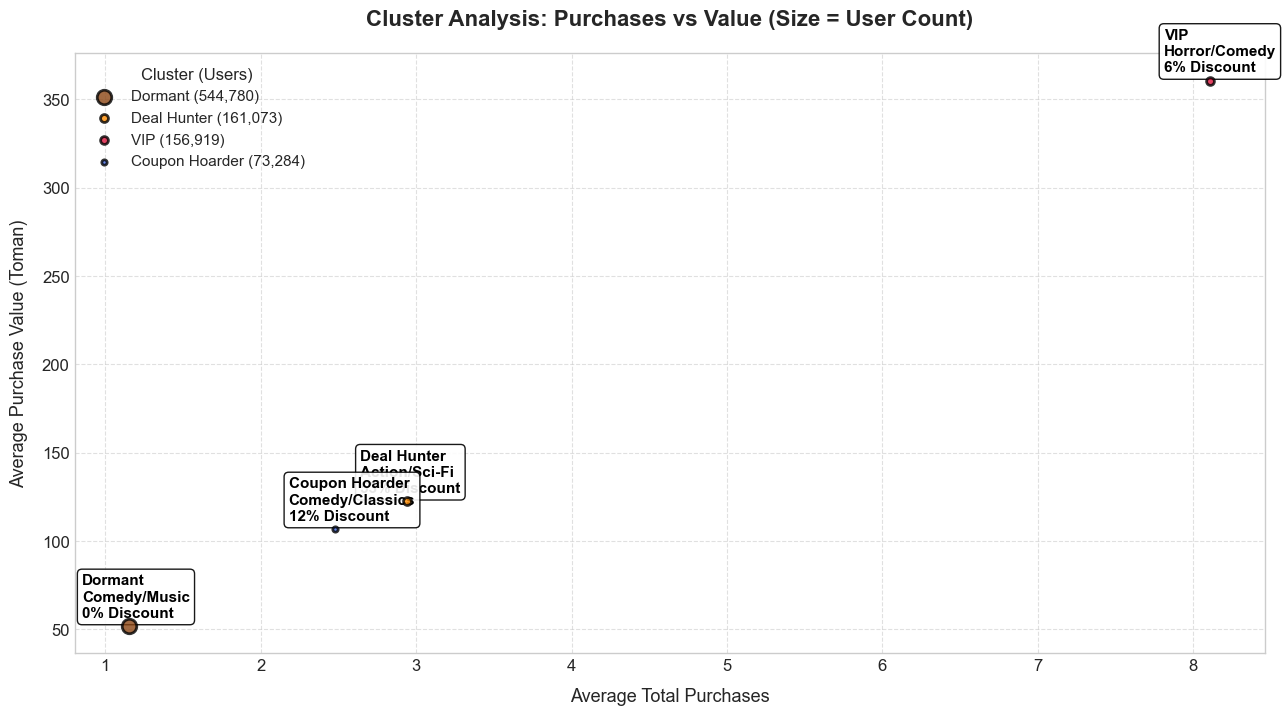

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# داده‌های خوشه‌ها
data = {
    'cluster': [0, 1, 2, 3],
    'name': ['Dormant', 'Deal Hunter', 'VIP', 'Coupon Hoarder'],
    'purchases': [1.15, 2.94, 8.11, 2.48],
    'value': [51.81, 122.43, 360.67, 106.71],
    'discount': [0, 53.26, 6.40, 11.72],
    'genre': ['Comedy/Music', 'Action/Sci-Fi', 'Horror/Comedy', 'Comedy/Classics'],
    'count': [544780, 161073, 156919, 73284]
}

df = pd.DataFrame(data)

# رنگ‌ها
colors = ['#8B4513', '#FF8C00', '#DC143C', '#4169E1']

plt.figure(figsize=(14, 8))

for i in range(4):
    row = df.iloc[i]
    size = row['count'] / 5000  # اندازه متناسب با تعداد
    
    plt.scatter(row['purchases'], row['value'], s=size, c=colors[i], 
                label=f"{row['name']} ({row['count']:,})", 
                edgecolors='black', linewidth=2, alpha=0.8, zorder=10)
    
    plt.text(row['purchases'] - 0.3 , row['value'] + 5, 
             f"{row['name']}\n{row['genre']}\n{row['discount']:.0f}% Discount", 
             fontsize=11, fontweight='bold', color='black',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    print(f"{row['name']}\n{row['genre']}\n{row['discount']:.0f}% Discount" , row['purchases'], row['value'])

plt.title('Cluster Analysis: Purchases vs Value (Size = User Count)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Average Total Purchases', fontsize=13, labelpad=10)
plt.ylabel('Average Purchase Value (Toman)', fontsize=13, labelpad=10)
plt.legend(title='Cluster (Users)', fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplots_adjust(bottom=0.15, top=0.9, left=0.1, right=0.95)

plt.show()


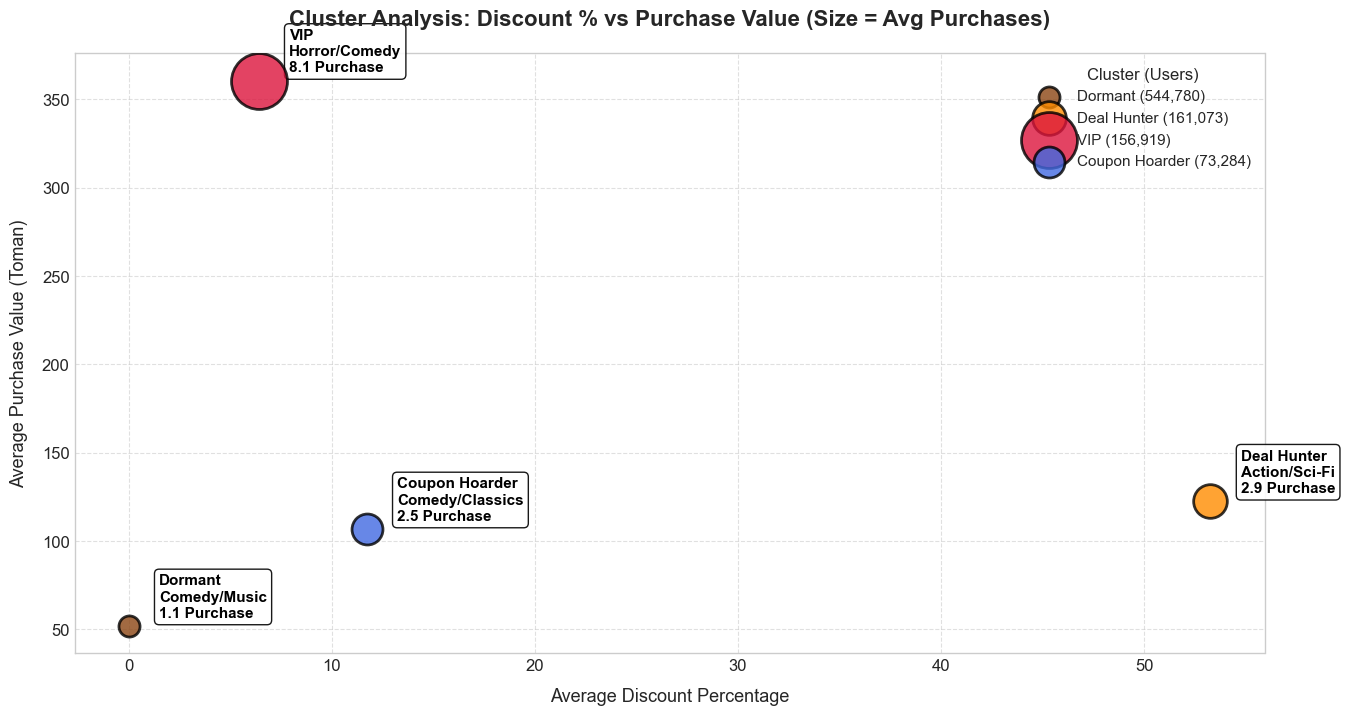

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data = {
    'cluster': [0, 1, 2, 3],
    'name': ['Dormant', 'Deal Hunter', 'VIP', 'Coupon Hoarder'],
    'purchases': [1.15, 2.94, 8.11, 2.48],
    'value': [51.81, 122.43, 360.67, 106.71],
    'discount': [0, 53.26, 6.40, 11.72],
    'genre': ['Comedy/Music', 'Action/Sci-Fi', 'Horror/Comedy', 'Comedy/Classics'],
    'count': [544780, 161073, 156919, 73284]
}

df = pd.DataFrame(data)

colors = ['#8B4513', '#FF8C00', '#DC143C', '#4169E1']

plt.figure(figsize=(14, 8))

for i in range(4):
    row = df.iloc[i]
    size = row['purchases'] * 200  # اندازه متناسب با تعداد خرید
    
    plt.scatter(row['discount'], row['value'], s=size, c=colors[i], 
                label=f"{row['name']} ({row['count']:,})", 
                edgecolors='black', linewidth=2, alpha=0.8, zorder=10)
    
    plt.text(row['discount'] + 1.5, row['value'] + 5, 
             f"{row['name']}\n{row['genre']}\n{row['purchases']:.1f} Purchase", 
             fontsize=11, fontweight='bold', color='black',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.title('Cluster Analysis: Discount % vs Purchase Value (Size = Avg Purchases)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Average Discount Percentage', fontsize=13, labelpad=10)
plt.ylabel('Average Purchase Value (Toman)', fontsize=13, labelpad=10)
plt.legend(title='Cluster (Users)', fontsize=11, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplots_adjust(bottom=0.15, top=0.9, left=0.1, right=0.95)

plt.show()


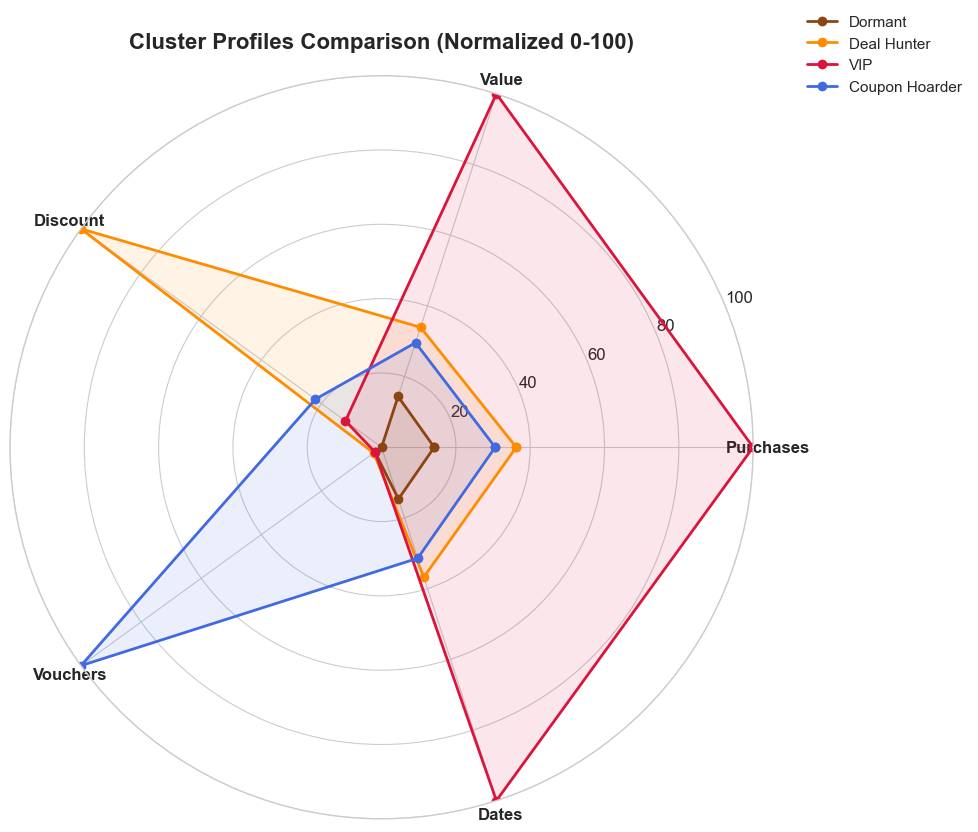

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# نرمال‌سازی داده‌ها بین ۰ تا ۱۰۰
categories = ['Purchases', 'Value', 'Discount', 'Vouchers', 'Dates']
N = len(categories)

values = {
    'Dormant': [1.15/8.11*100, 51.81/360.67*100, 0, 0.05/2.29*100, 1.13/7.70*100],
    'Deal Hunter': [2.94/8.11*100, 122.43/360.67*100, 53.26/53.26*100, 0.06/2.29*100, 2.83/7.70*100],
    'VIP': [8.11/8.11*100, 360.67/360.67*100, 6.40/53.26*100, 0.05/2.29*100, 7.70/7.70*100],
    'Coupon Hoarder': [2.48/8.11*100, 106.71/360.67*100, 11.72/53.26*100, 2.29/2.29*100, 2.42/7.70*100]
}

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors = ['#8B4513', '#FF8C00', '#DC143C', '#4169E1']
names = ['Dormant', 'Deal Hunter', 'VIP', 'Coupon Hoarder']

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i, (name, vals) in enumerate(values.items()):
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=f'{name}', color=colors[i])
    ax.fill(angles, vals, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_title('Cluster Profiles Comparison (Normalized 0-100)', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.show()



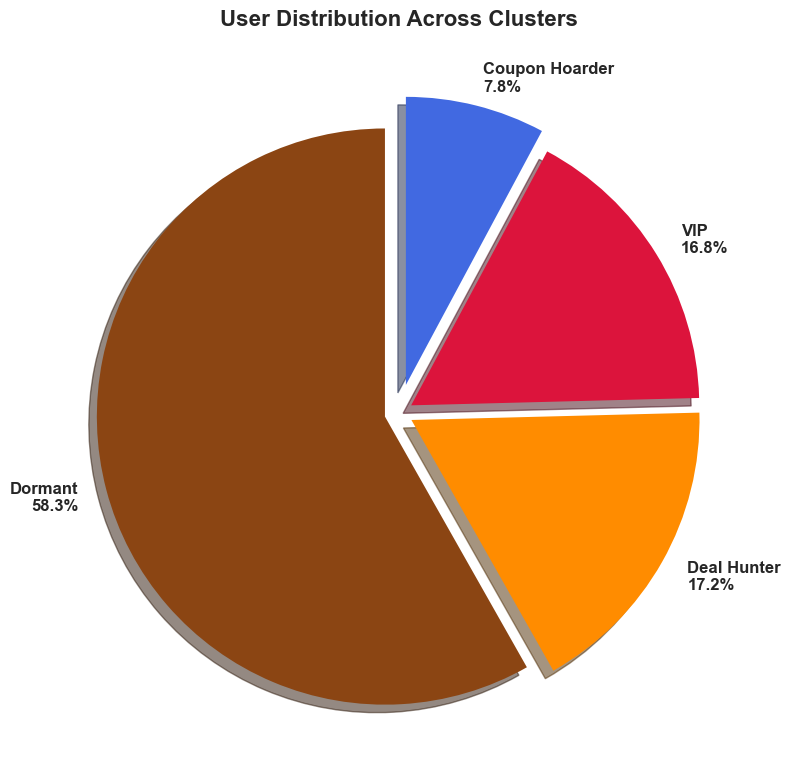

In [40]:
import matplotlib.pyplot as plt

sizes = [544780, 161073, 156919, 73284]
labels = ['Dormant\n58.3%', 'Deal Hunter\n17.2%', 'VIP\n16.8%', 'Coupon Hoarder\n7.8%']
colors = ['#8B4513', '#FF8C00', '#DC143C', '#4169E1']
explode = (0.05, 0.05, 0.05, 0.1)

plt.figure(figsize=(10, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='', startangle=90, shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('User Distribution Across Clusters', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


R² = 0.999


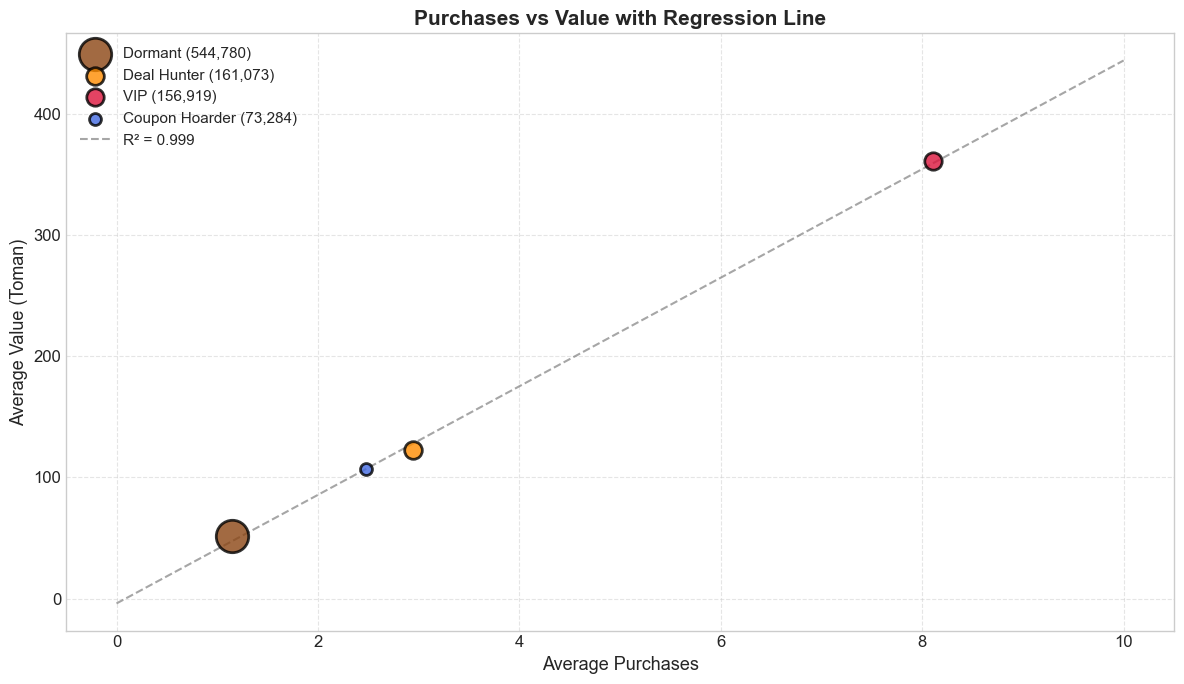

In [42]:
import matplotlib.pyplot as plt
import numpy as np

purchases = [1.15, 2.94, 8.11, 2.48]
values = [51.81, 122.43, 360.67, 106.71]
users = [544780, 161073, 156919, 73284]
names = ['Dormant', 'Deal Hunter', 'VIP', 'Coupon Hoarder']
colors = ['#8B4513', '#FF8C00', '#DC143C', '#4169E1']

plt.figure(figsize=(12, 7))

# نقاط
for i in range(4):
    plt.scatter(purchases[i], values[i], s=users[i]/1000, 
                c=colors[i], edgecolors='black', linewidth=2, 
                alpha=0.8, zorder=5, label=f'{names[i]} ({users[i]:,})')

# خط رگرسیون
z = np.polyfit(purchases, values, 1)
p = np.poly1d(z)
x_line = np.linspace(0, 10, 100)
plt.plot(x_line, p(x_line), '--', color='gray', alpha=0.7, 
         label=f'R² = {np.corrcoef(purchases, values)[0,1]**2:.3f}')
print(f'R² = {np.corrcoef(purchases, values)[0,1]**2:.3f}')
plt.xlabel('Average Purchases', fontsize=13)
plt.ylabel('Average Value (Toman)', fontsize=13)
plt.title('Purchases vs Value with Regression Line', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


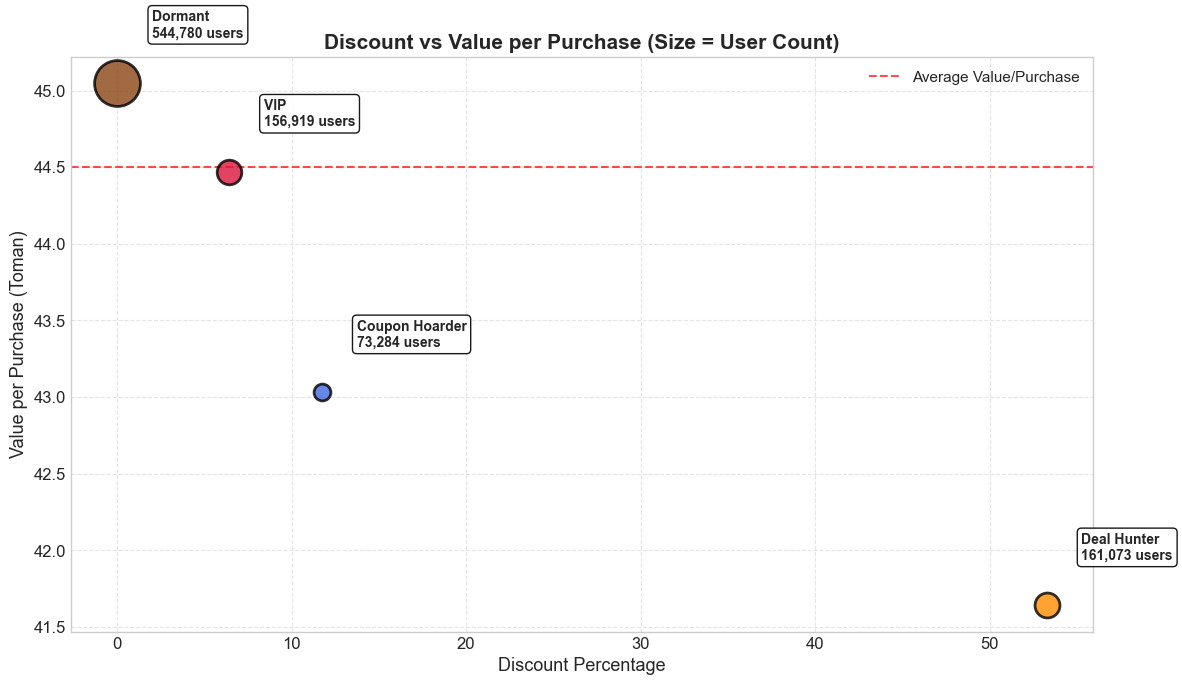

In [44]:
import matplotlib.pyplot as plt

clusters = ['Dormant', 'Deal Hunter', 'VIP', 'Coupon Hoarder']
discounts = [0, 53.26, 6.40, 11.72]
value_per_purchase = [45.05, 41.64, 44.47, 43.03]
users = [544780, 161073, 156919, 73284]
colors = ['#8B4513', '#FF8C00', '#DC143C', '#4169E1']

plt.figure(figsize=(12, 7))

for i in range(4):
    plt.scatter(discounts[i], value_per_purchase[i], 
                s=users[i]/500, c=colors[i], edgecolors='black',
                linewidth=2, alpha=0.8, zorder=5)
    
    plt.text(discounts[i] + 2, value_per_purchase[i] + 0.3,
             f"{clusters[i]}\n{users[i]:,} users",
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.axhline(y=44.5, color='red', linestyle='--', alpha=0.7, label='Average Value/Purchase')
plt.xlabel('Discount Percentage', fontsize=13)
plt.ylabel('Value per Purchase (Toman)', fontsize=13)
plt.title('Discount vs Value per Purchase (Size = User Count)', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
